# Blocco dei metodi a margine e delle reti: SVR con tre kernel, percettrone multistrato

Questo notebook analizza il quarto e ultimo blocco del confronto fra modelli sul dataset NASA
C-MAPSS (Turbofan Engine Degradation Simulation), nel quale la variabile da predire e' la vita
utile residua di un motore aeronautico, espressa in cicli di funzionamento e censurata a 125
cicli.

I dati provengono dai file grezzi del NASA Prognostics Data Repository, collocati in `data/raw/`
e non versionati. Il perimetro sperimentale comprende i sottoinsiemi FD001 (un solo modo di
guasto) e FD003 (due modi di guasto), entrambi a regime operativo unico. Ogni riga della matrice
di progetto e' un ciclo di funzionamento di un motore, descritto dal numero di ciclo, dalle
impostazioni operative e dalle letture dei sensori non costanti: 18 variabili su FD001 e 19 su
FD003.

## Cosa contiene questo notebook

I quattro modelli confrontati qui stimano una funzione non lineare senza costruire esplicitamente
un'espansione delle variabili, ed e' cio' che li distingue dal blocco che supera la linearita'. La
regressione a vettori di supporto minimizza una perdita che ignora gli errori dentro una banda di
ampiezza fissata e penalizza la complessita' della funzione: la forma della funzione dipende dal
kernel, che qui compare nelle tre varianti lineare, radiale e polinomiale. Il percettrone
multistrato compone trasformazioni affini e non linearita' elementari, e la sua flessibilita'
dipende dall'architettura e da dove la stima viene fermata.

La domanda a cui il blocco risponde e' se una funzione non lineare stimata implicitamente, per
kernel o per composizione, colga qualcosa che le partizioni ricorsive del blocco ad albero e le
espansioni additive del blocco precedente non colgono.

Il notebook non addestra modelli e non esegue lavoro computazionale: legge gli artefatti gia'
prodotti dagli script di esperimento e ne ricava figure, tabelle e lettura dei risultati. Puo'
quindi essere eseguito dall'inizio alla fine in pochi secondi, e gli stessi numeri che compaiono
qui esistono su disco in forma tabellare, indipendentemente dal notebook.

Gli artefatti letti sono prodotti da:

    python -m scripts.measure_kernel_costs
    python -m scripts.run_kernel_models

Il primo comando misura i costi della stima, il comportamento del kernel polinomiale al variare
del grado e la convergenza della rete, e precede la scelta delle griglie; il secondo esegue
l'esperimento. Il confronto con i blocchi precedenti usa gli artefatti di
`python -m scripts.run_linear_models`, `python -m scripts.run_nonlinear_models` e
`python -m scripts.run_tree_models`, gia' prodotti e non rieseguiti qui.

## Protocollo sotto cui i risultati sono stati prodotti

Il partizionamento avviene per unita' motore: tutte le righe di una stessa traiettoria restano
dalla stessa parte della verifica, perche' cicli consecutivi dello stesso motore non sono
osservazioni indipendenti. Lo schema e' un K-Fold con vincolo di gruppo a 5 fold, ripetuto su tre
semi. La ricerca degli iperparametri opera sulle 5 partizioni di un seme dedicato; la sola
configurazione selezionata viene poi rivalutata sulle 15 partizioni dei tre semi, e sono quei 15
punteggi a produrre media e dispersione riportate.

La metrica di riferimento e' la radice dell'errore quadratico medio, nelle unita' del target.
Errore assoluto medio e coefficiente di determinazione accompagnano la lettura e non partecipano
alla selezione. La standardizzazione e' dentro la pipeline di tutti i modelli e per questi non e'
irrilevante come lo era per gli alberi: sia la distanza che entra nel kernel radiale sia il
prodotto interno che entra in quello polinomiale sia la scala dei pesi iniziali della rete
dipendono dalle unita' delle variabili.

La dispersione riportata e' calcolata sui fold e non e' l'errore standard della media: i fold
condividono le righe di addestramento. Due modelli il cui divario e' inferiore alla dispersione
non sono distinguibili sotto questo protocollo e non vengono ordinati.

In [1]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# I percorsi sono ricavati dalla posizione del notebook, non dalla directory di lavoro, cosi'
# che l'esecuzione non dipenda da dove viene avviato il kernel.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
KERNEL_DIR = PROJECT_ROOT / "experiments" / "kernel_models"
TREE_DIR = PROJECT_ROOT / "experiments" / "tree_models"
NONLINEAR_DIR = PROJECT_ROOT / "experiments" / "nonlinear_models"
LINEAR_DIR = PROJECT_ROOT / "experiments" / "linear_models"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

SUBSETS = ("FD001", "FD003")
MODELS = ("svr_linear", "svr_rbf", "svr_poly", "mlp")
KERNELS = ("linear", "rbf", "poly")

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})


def load(directory, subset, name):
    return pd.read_csv(directory / f"{subset}_{name}.csv")


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"{name}.png", bbox_inches="tight")


comparison = {s: load(KERNEL_DIR, s, "comparison") for s in SUBSETS}
folds = {s: load(KERNEL_DIR, s, "cv_folds") for s in SUBSETS}
grids = {s: load(KERNEL_DIR, s, "grids") for s in SUBSETS}
permutation = {s: load(KERNEL_DIR, s, "permutation_importances") for s in SUBSETS}
diagnostics = {s: load(KERNEL_DIR, s, "diagnostics") for s in SUBSETS}

# Artefatti della sonda dei costi, che precede l'esperimento e non ne fa parte. Le sue misure
# sono su una sola partizione e non sono stime di prestazione.
probe = {s: load(KERNEL_DIR, s, "kernel_cost_probe") for s in SUBSETS}
network_probe = {s: load(KERNEL_DIR, s, "mlp_cost_probe") for s in SUBSETS}

previous = {}
for s in SUBSETS:
    blocks = pd.concat([load(LINEAR_DIR, s, "comparison"),
                        load(NONLINEAR_DIR, s, "comparison"),
                        load(TREE_DIR, s, "comparison")], ignore_index=True)
    previous[s] = blocks[~blocks["model"].str.startswith("baseline")]

LABELS = {row["model"]: row["label"] for s in SUBSETS for _, row in comparison[s].iterrows()}


# Miglior modello dei tre blocchi gia' conclusi, escluse le baseline.
def best_previous(subset):
    table = previous[subset]
    return table.loc[table["rmse_mean"].idxmin()]


def grid_of(subset, model):
    block = grids[subset].query("model == @model").copy()
    return block.dropna(axis=1, how="all")


# Riga della griglia corrispondente alla configurazione selezionata.
def selected_row(subset, model):
    return grid_of(subset, model).sort_values("rank_test_rmse").iloc[0]


# Numero complessivo di unita' nascoste, per ordinare l'asse delle architetture.
def units(architecture):
    return sum(ast.literal_eval(architecture))

## 1. Confronto fra i modelli del blocco

I quattro modelli vedono la stessa matrice, le stesse partizioni e lo stesso pre-processing dei
modelli dei tre blocchi precedenti. Le due baseline sono ricalcolate qui e non riprese dagli
artefatti degli altri blocchi, cosi' che la tabella sia prodotta interamente da una sola
esecuzione: la predizione costante e' il pavimento assoluto, la regressione sul solo numero di
ciclo e' il pavimento informativo.

La colonna con il numero di variabili attive e' definita per la sola variante a kernel lineare, la
cui funzione stimata resta lineare nelle variabili e ha quindi coefficienti confrontabili con
quelli dei blocchi precedenti. Per gli altri tre modelli resta vuota: riempirla con il numero di
vettori di supporto vi metterebbe una quantita' diversa sotto la stessa intestazione. I vettori di
supporto sono riportati nella sezione dedicata.

In [2]:
for subset in SUBSETS:
    table = comparison[subset][["label", "config", "n_nonzero", "rmse_mean", "rmse_std",
                                "divario_in_dispersioni", "mae_mean", "r2_mean"]]
    table.to_csv(TABLES_DIR / f"{subset}_confronto_blocco_margine.csv", index=False)
    print(f"\n{subset}")
    print(table.to_string(index=False))


FD001
                               label                                                            config  n_nonzero  rmse_mean  rmse_std  divario_in_dispersioni  mae_mean   r2_mean
             Percettrone multistrato hidden_layer_sizes=(16,), learning_rate_init=0.001, max_iter=1000        NaN  16.580777  1.395502                    0.00 11.576623  0.840441
                 SVR, kernel radiale                                     C=100, epsilon=8, gamma=0.015        NaN  16.960918  1.410801                    0.27 12.299141  0.833098
                 SVR, kernel lineare                                                C=0.01, epsilon=16       18.0  20.320268  1.115107                    2.96 16.563192  0.761307
             SVR, kernel polinomiale                                      C=10, epsilon=16, gamma=0.06        NaN  23.354282  0.926122                    5.72 19.050876  0.685111
Regressione sul solo numero di ciclo                                                          base

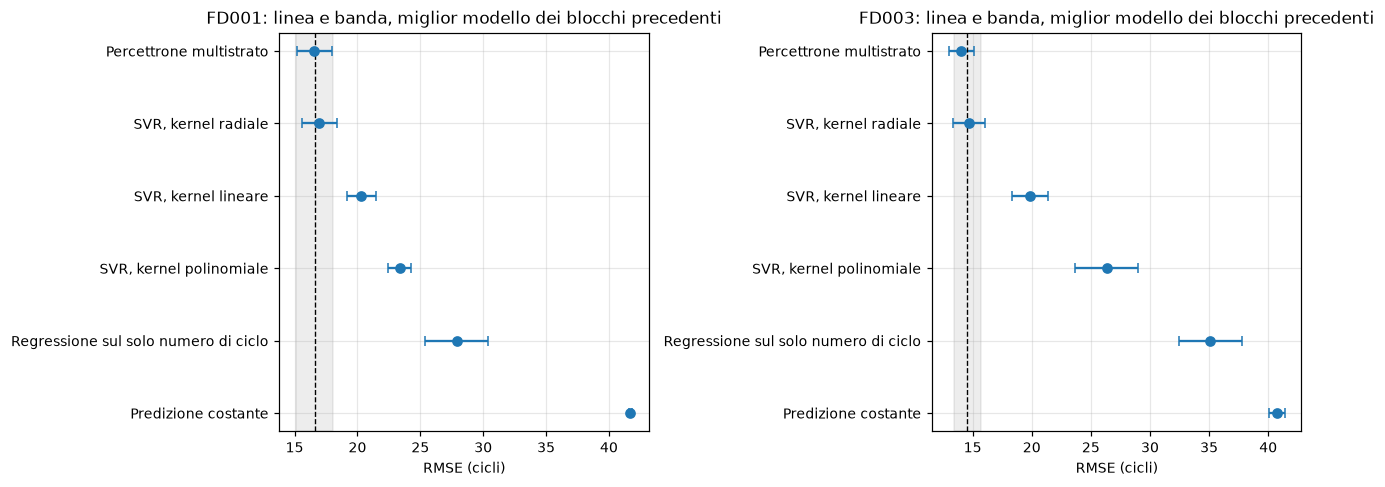

In [3]:
fig, axes = plt.subplots(1, len(SUBSETS), figsize=(12, 4.5))
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    table = comparison[subset].sort_values("rmse_mean", ascending=False)
    ax.errorbar(table["rmse_mean"], range(len(table)), xerr=table["rmse_std"], fmt="o", capsize=3)
    reference = best_previous(subset)
    ax.axvline(reference["rmse_mean"], color="black", linewidth=0.9, linestyle="--")
    ax.axvspan(reference["rmse_mean"] - reference["rmse_std"],
               reference["rmse_mean"] + reference["rmse_std"], color="black", alpha=0.07)
    ax.set_yticks(range(len(table)))
    ax.set_yticklabels(table["label"])
    ax.set_xlabel("RMSE (cicli)")
    ax.set_title(f"{subset}: linea e banda, miglior modello dei blocchi precedenti")
save(fig, "confronto_blocco_margine")
plt.show()

In [4]:
rows = []
for subset in SUBSETS:
    reference = best_previous(subset)
    for model in MODELS:
        row = comparison[subset].query("model == @model").iloc[0]
        scale = np.sqrt((row["rmse_std"] ** 2 + reference["rmse_std"] ** 2) / 2.0)
        rows.append({
            "sottoinsieme": subset,
            "modello": row["label"],
            "rmse": row["rmse_mean"],
            "dispersione": row["rmse_std"],
            "riferimento_precedente": reference["label"],
            "rmse_riferimento": reference["rmse_mean"],
            "guadagno_cicli": reference["rmse_mean"] - row["rmse_mean"],
            "guadagno_in_dispersioni": (reference["rmse_mean"] - row["rmse_mean"]) / scale,
        })
guadagno = pd.DataFrame(rows)
guadagno.to_csv(TABLES_DIR / "guadagno_blocco_margine.csv", index=False)
guadagno

,sottoinsieme,modello,rmse,dispersione,riferimento_precedente,rmse_riferimento,guadagno_cicli,guadagno_in_dispersioni
0,FD001,"SVR, kernel lineare",20.320268,1.115107,Foresta casuale,16.594991,-3.725277,-2.865566
1,FD001,"SVR, kernel radiale",16.960918,1.410801,Foresta casuale,16.594991,-0.365927,-0.254738
2,FD001,"SVR, kernel polinomiale",23.354282,0.926122,Foresta casuale,16.594991,-6.759291,-5.524177
3,FD001,Percettrone multistrato,16.580777,1.395502,Foresta casuale,16.594991,0.014214,0.009947
4,FD003,"SVR, kernel lineare",19.826377,1.518421,XGBoost,14.557526,-5.268851,-3.963692
5,FD003,"SVR, kernel radiale",14.675923,1.366376,XGBoost,14.557526,-0.118397,-0.095170
6,FD003,"SVR, kernel polinomiale",26.335170,2.668965,XGBoost,14.557526,-11.777644,-5.763483
7,FD003,Percettrone multistrato,14.042110,1.056929,XGBoost,14.557526,0.515416,0.475947


La figura riporta la media sui 15 fold con la dispersione fra fold; la linea tratteggiata e la
banda grigia sono il miglior modello dei tre blocchi gia' conclusi, cioe' il livello che questo
blocco doveva superare per aggiungere qualcosa al confronto.

Tre letture, in ordine di robustezza.

La rete e il kernel radiale raggiungono il livello del riferimento e non lo superano in modo
leggibile. Il guadagno in unita' di dispersione, riportato nella tabella, e' una frazione di
dispersione su entrambi i sottoinsiemi: la regola di lettura del progetto non ordina risultati a
quella distanza, quindi la conclusione difendibile e' che due famiglie molto diverse fra loro
arrivino allo stesso punto, non che una vinca. Questo vale anche quando il numero piu' basso della
tabella e' di questo blocco, ed e' il motivo per cui la colonna del divario in dispersioni sta
accanto a quella delle medie.

Le due varianti di kernel restanti stanno molto indietro, e la distanza fra loro e le altre due
righe e' invece leggibile. Il kernel lineare arriva dove arrivano i modelli lineari, il che e'
atteso: la funzione che stima e' della stessa forma, e cambia solo la perdita minimizzata. Il
kernel polinomiale e' peggiore del kernel lineare su entrambi i sottoinsiemi, ed e' l'unico
risultato del blocco che richiede una spiegazione, data nella sezione sul costo della stima.

Il confronto fra i due sottoinsiemi ha la stessa asimmetria dei blocchi precedenti. Il divario fra
il modello migliore e la baseline sul solo numero di ciclo e' molto piu' ampio su FD003, dove il
conteggio dei cicli da solo e' un predittore debole perche' due modi di guasto producono
traiettorie di durata diversa a parita' di degrado osservato.

## 2. Comportamento dei modelli lungo la griglia

Il punteggio del modello selezionato non dice se il minimo sia netto o se la curva sia piatta. La
distinzione conta: su una curva piatta la configurazione scelta e' una fra molte equivalenti, e la
selezione non e' un risultato stabile. Le curve riportano l'errore in cross-validation di ogni
configurazione esplorata, sulle 5 partizioni usate per la ricerca.

Le griglie hanno da due a tre assi, quindi le curve mostrano sezioni che passano per la
configurazione selezionata. Per le tre varianti di kernel gli assi comuni sono la penalizzazione e
la banda di insensibilita'; l'ampiezza del kernel esiste per le sole varianti radiale e
polinomiale, con griglie diverse per la ragione numerica discussa piu' avanti. Per la rete gli
assi sono architettura, passo di apprendimento e numero di iterazioni.

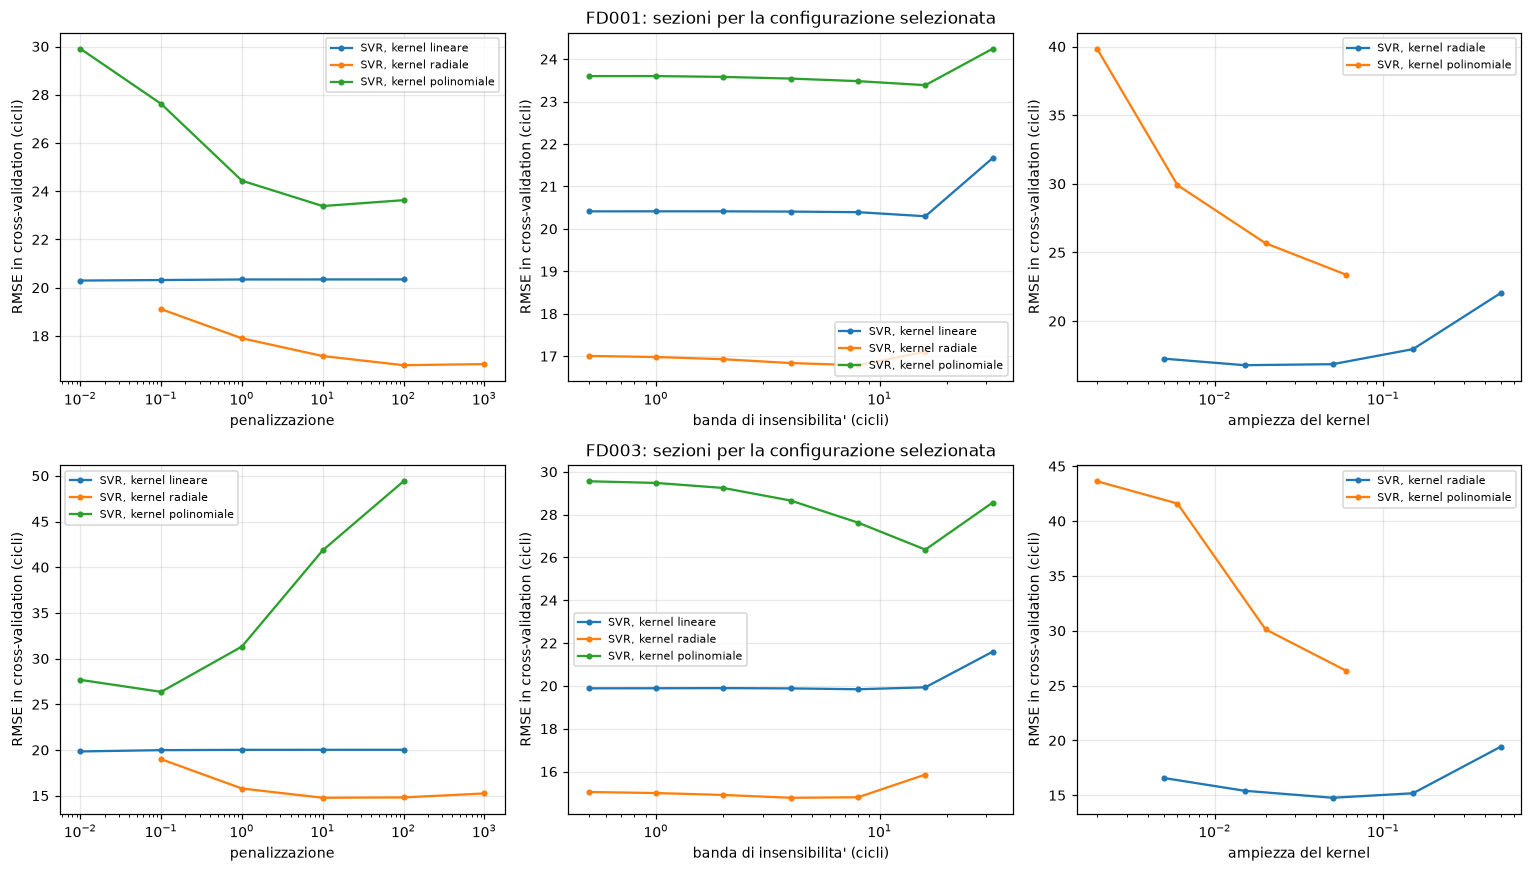

In [5]:
fig, axes = plt.subplots(len(SUBSETS), 3, figsize=(14, 4.0 * len(SUBSETS)))
axes = np.atleast_2d(axes)
for row_axes, subset in zip(axes, SUBSETS):
    for model in ("svr_linear", "svr_rbf", "svr_poly"):
        block = grid_of(subset, model)
        best = selected_row(subset, model)

        section = block[block["param_model__epsilon"] == best["param_model__epsilon"]]
        if "param_model__gamma" in block.columns:
            section = section[section["param_model__gamma"] == best["param_model__gamma"]]
        section = section.sort_values("param_model__C")
        row_axes[0].plot(section["param_model__C"], section["mean_test_rmse"],
                         marker=".", label=LABELS[model])

        section = block[block["param_model__C"] == best["param_model__C"]]
        if "param_model__gamma" in block.columns:
            section = section[section["param_model__gamma"] == best["param_model__gamma"]]
        section = section.sort_values("param_model__epsilon")
        row_axes[1].plot(section["param_model__epsilon"], section["mean_test_rmse"],
                         marker=".", label=LABELS[model])

        if "param_model__gamma" in block.columns:
            section = block[(block["param_model__C"] == best["param_model__C"])
                            & (block["param_model__epsilon"] == best["param_model__epsilon"])]
            section = section.sort_values("param_model__gamma")
            row_axes[2].plot(section["param_model__gamma"], section["mean_test_rmse"],
                             marker=".", label=LABELS[model])

    row_axes[0].set_xscale("log")
    row_axes[0].set_xlabel("penalizzazione")
    row_axes[1].set_xscale("log")
    row_axes[1].set_xlabel("banda di insensibilita' (cicli)")
    row_axes[2].set_xscale("log")
    row_axes[2].set_xlabel("ampiezza del kernel")
    for ax in row_axes:
        ax.set_ylabel("RMSE in cross-validation (cicli)")
        ax.legend(fontsize=7)
    row_axes[1].set_title(f"{subset}: sezioni per la configurazione selezionata")
save(fig, "curve_griglie_margine")
plt.show()

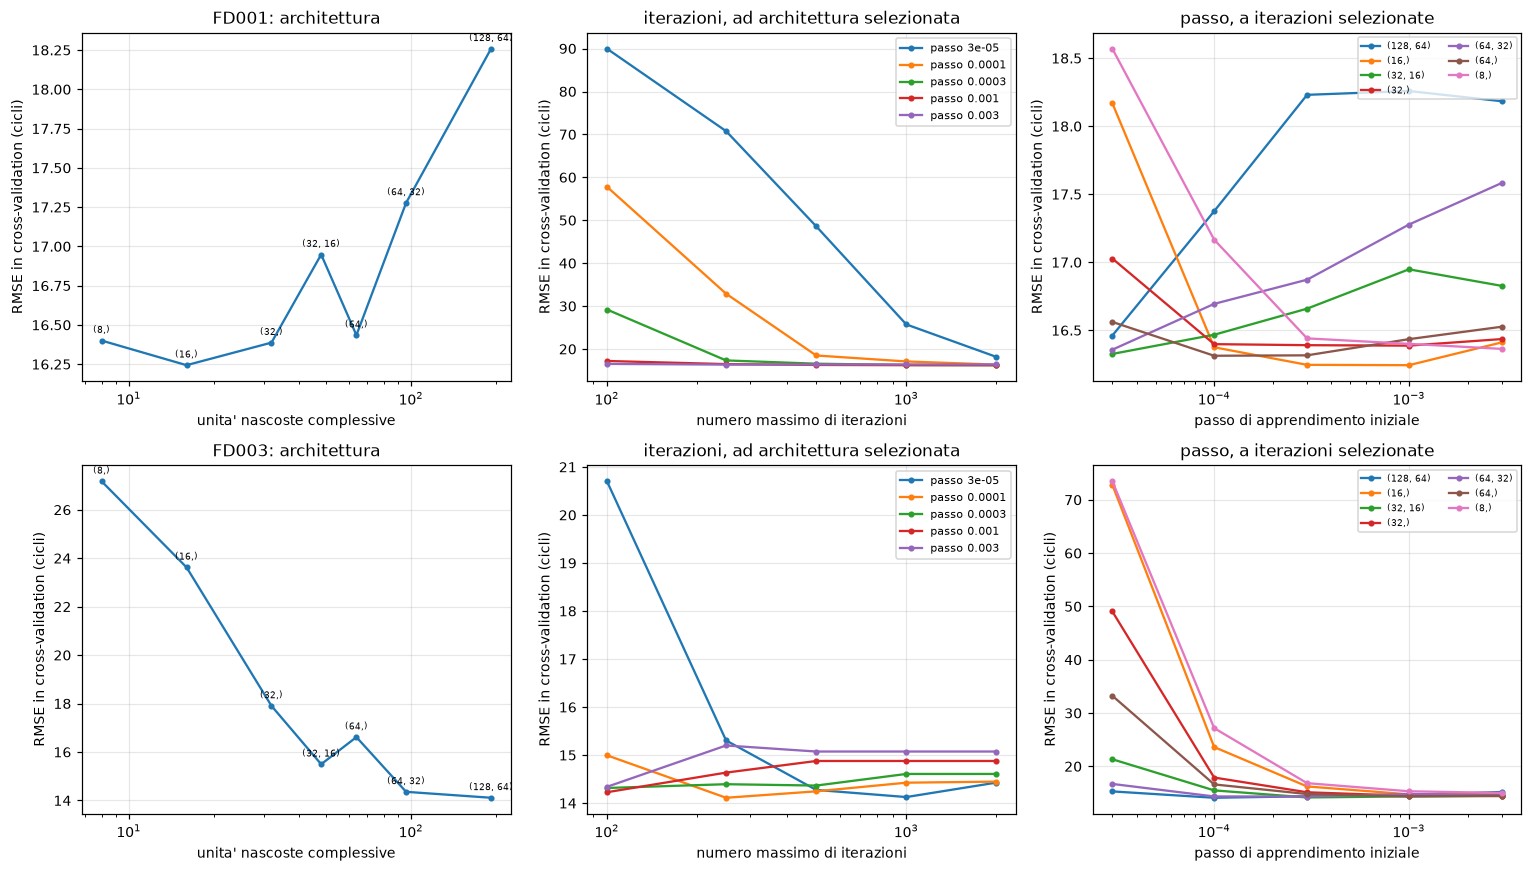

In [6]:
fig, axes = plt.subplots(len(SUBSETS), 3, figsize=(14, 4.0 * len(SUBSETS)))
axes = np.atleast_2d(axes)
for row_axes, subset in zip(axes, SUBSETS):
    block = grid_of(subset, "mlp")
    best = selected_row(subset, "mlp")

    section = block[(block["param_model__learning_rate_init"] == best["param_model__learning_rate_init"])
                    & (block["param_model__max_iter"] == best["param_model__max_iter"])].copy()
    section["unita"] = section["param_model__hidden_layer_sizes"].map(units)
    section = section.sort_values("unita")
    row_axes[0].plot(section["unita"], section["mean_test_rmse"], marker=".")
    for _, point in section.iterrows():
        row_axes[0].annotate(point["param_model__hidden_layer_sizes"],
                             (point["unita"], point["mean_test_rmse"]),
                             fontsize=6, xytext=(0, 5), textcoords="offset points", ha="center")
    row_axes[0].set_xscale("log")
    row_axes[0].set_xlabel("unita' nascoste complessive")
    row_axes[0].set_title(f"{subset}: architettura")

    section = block[block["param_model__hidden_layer_sizes"] == best["param_model__hidden_layer_sizes"]]
    for rate, part in section.groupby("param_model__learning_rate_init"):
        part = part.sort_values("param_model__max_iter")
        row_axes[1].plot(part["param_model__max_iter"], part["mean_test_rmse"],
                         marker=".", label=f"passo {rate:g}")
    row_axes[1].set_xscale("log")
    row_axes[1].set_xlabel("numero massimo di iterazioni")
    row_axes[1].set_title("iterazioni, ad architettura selezionata")
    row_axes[1].legend(fontsize=7)

    section = block[block["param_model__max_iter"] == best["param_model__max_iter"]].copy()
    section["unita"] = section["param_model__hidden_layer_sizes"].map(units)
    for architecture, part in section.groupby("param_model__hidden_layer_sizes"):
        part = part.sort_values("param_model__learning_rate_init")
        row_axes[2].plot(part["param_model__learning_rate_init"], part["mean_test_rmse"],
                         marker=".", label=architecture)
    row_axes[2].set_xscale("log")
    row_axes[2].set_xlabel("passo di apprendimento iniziale")
    row_axes[2].set_title("passo, a iterazioni selezionate")
    row_axes[2].legend(fontsize=6, ncol=2)

    for ax in row_axes:
        ax.set_ylabel("RMSE in cross-validation (cicli)")
save(fig, "curve_griglie_rete")
plt.show()

In [7]:
rows = []
for subset in SUBSETS:
    for model in MODELS:
        block = grids[subset].query("model == @model")
        best = block["mean_test_rmse"].min()
        rows.append({
            "sottoinsieme": subset,
            "modello": LABELS[model],
            "configurazioni": len(block),
            "rmse_minimo": best,
            "rmse_massimo": block["mean_test_rmse"].max(),
            "escursione_griglia": block["mean_test_rmse"].max() - best,
            "configurazioni_entro_un_ciclo": int((block["mean_test_rmse"] <= best + 1.0).sum()),
            "quota_entro_un_ciclo": float((block["mean_test_rmse"] <= best + 1.0).mean()),
        })
piattezza = pd.DataFrame(rows)
piattezza.to_csv(TABLES_DIR / "piattezza_griglie_margine.csv", index=False)
piattezza

,sottoinsieme,modello,configurazioni,rmse_minimo,rmse_massimo,escursione_griglia,configurazioni_entro_un_ciclo,quota_entro_un_ciclo
0,FD001,"SVR, kernel lineare",35,20.298220,21.670131,1.371911,34,0.971429
1,FD001,"SVR, kernel radiale",150,16.789387,42.749709,25.960322,57,0.380000
2,FD001,"SVR, kernel polinomiale",140,23.386799,44.610957,21.224158,20,0.142857
3,FD001,Percettrone multistrato,175,16.243872,91.613679,75.369806,111,0.634286
4,FD003,"SVR, kernel lineare",35,19.845942,21.601459,1.755517,30,0.857143
5,FD003,"SVR, kernel radiale",150,14.778071,44.077638,29.299567,49,0.326667
6,FD003,"SVR, kernel polinomiale",140,26.367373,50.731539,24.364166,3,0.021429
7,FD003,Percettrone multistrato,175,14.112629,94.077090,79.964461,115,0.657143


Le due figure mostrano comportamenti opposti, e la differenza e' il contenuto principale della
sezione.

Le sezioni delle varianti di kernel hanno minimi netti su almeno un asse. L'ampiezza del kernel
radiale ha un minimo interno su entrambi i sottoinsiemi, con salita ripida su entrambi i lati: e'
l'asse che governa quanto localmente il modello interpola, e la sua curva a U e' la forma attesa
di un compromesso fra distorsione e varianza. La penalizzazione ha invece un profilo piatto per il
kernel lineare, dove quattro decadi producono meno di un decimo di ciclo di variazione, e un
profilo in discesa netta per il kernel radiale, che passa da 19,1 a 16,8 cicli su FD001. Sul
kernel lineare la selezione dell'estremo e' quindi indistinguibile dal rumore, mentre sul kernel
radiale e' una scelta con contenuto.

La banda di insensibilita' ha effetti piccoli finche' resta molto sotto la dispersione del target,
e peggiora nettamente all'estremo superiore delle due griglie che arrivano a 32 cicli, dove la
banda copre quasi l'intera escursione e il modello degenera verso una funzione costante.

La superficie della rete e' piatta rispetto alle prime due dimensioni e non lo e' rispetto alla
terza. Le configurazioni entro un ciclo dal minimo, riportate in tabella, sono una quota rilevante
della griglia: passo e numero di iterazioni si scambiano fra loro senza spostare il risultato, il
che e' coerente con il fatto che entrambi governano la stessa cosa, cioe' quanto lontano la stima
arriva prima di fermarsi. L'architettura invece separa: su FD001 il profilo peggiora al crescere
delle unita' nascoste, su FD003 migliora, e la differenza fra i due sottoinsiemi e' di parecchie
dispersioni. E' il punto in cui i due modi di guasto di FD003 diventano visibili come richiesta di
capacita' aggiuntiva.

## 3. La banda di insensibilita' e i vettori di supporto

I vettori di supporto sono le righe che cadono sul bordo della banda o fuori da essa, cioe' quelle
che determinano la soluzione: la funzione stimata dipende soltanto da loro. La loro frazione e' la
misura di complessita' propria di questa famiglia, e ha la stessa funzione che il numero di
coefficienti non annullati ha nel blocco lineare.

La frazione e' governata direttamente dalla banda, e le due quantita' sono la stessa lettura vista
dal lato del parametro e dal lato della soluzione. La figura usa le misure della sonda dei costi,
che varia la banda tenendo fermo il resto su una sola partizione; la tabella riporta invece i
modelli selezionati dall'esperimento, riaddestrati sull'intera parte di addestramento.

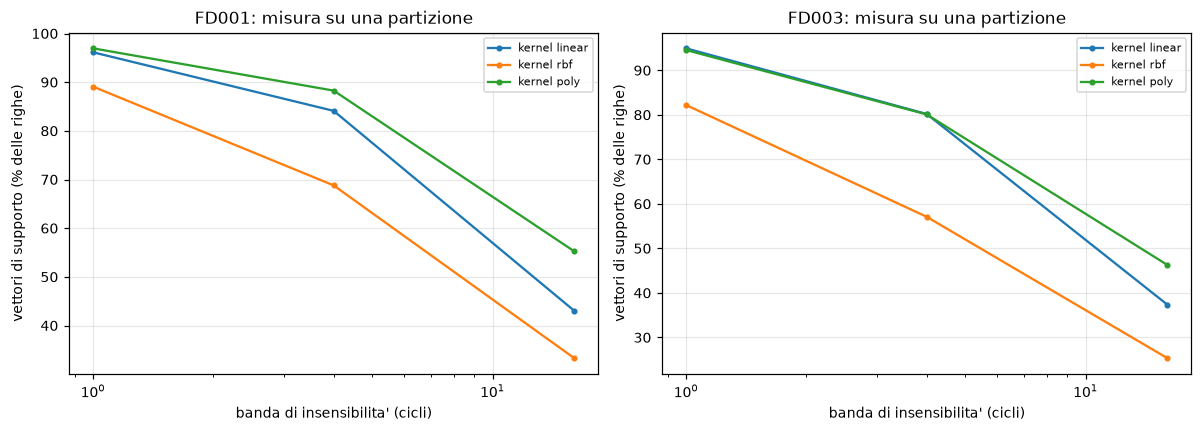

In [8]:
sensitivity = {s: probe[s].query("block == 'sensitivity' and status == 'ok'") for s in SUBSETS}

fig, axes = plt.subplots(1, len(SUBSETS), figsize=(11, 4))
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    block = sensitivity[subset]
    for kernel in KERNELS:
        part = block[block["kernel"] == kernel]
        # L'asse della banda e' la sezione in cui penalizzazione e ampiezza restano al centro.
        centre_c = part["C"].mode().iloc[0]
        part = part[part["C"] == centre_c]
        if kernel != "linear":
            part = part[part["gamma"] == part["gamma"].mode().iloc[0]]
        part = part.sort_values("epsilon")
        ax.plot(part["epsilon"], 100 * part["support_share"], marker=".", label=f"kernel {kernel}")
    ax.set_xscale("log")
    ax.set_xlabel("banda di insensibilita' (cicli)")
    ax.set_ylabel("vettori di supporto (% delle righe)")
    ax.set_title(f"{subset}: misura su una partizione")
    ax.legend(fontsize=7)
save(fig, "vettori_di_supporto_banda")
plt.show()

In [9]:
rows = []
for subset in SUBSETS:
    block = diagnostics[subset].set_index("model")
    for model in ("svr_linear", "svr_rbf", "svr_poly"):
        row = block.loc[model]
        rows.append({
            "sottoinsieme": subset,
            "modello": LABELS[model],
            "banda_selezionata": row["epsilon"],
            "vettori_di_supporto": int(row["n_support"]),
            "quota_vettori_di_supporto": row["support_share"],
            "iterazioni_stima": int(row["n_iter"]),
        })
soluzione = pd.DataFrame(rows)
soluzione.to_csv(TABLES_DIR / "vettori_di_supporto_margine.csv", index=False)
soluzione

,sottoinsieme,modello,banda_selezionata,vettori_di_supporto,quota_vettori_di_supporto,iterazioni_stima
0,FD001,"SVR, kernel lineare",16.0,9174,0.444671,5439
1,FD001,"SVR, kernel radiale",8.0,10073,0.488246,68687
2,FD001,"SVR, kernel polinomiale",16.0,10776,0.522321,337406
3,FD003,"SVR, kernel lineare",8.0,15933,0.644539,9142
4,FD003,"SVR, kernel radiale",4.0,12789,0.517354,20110
5,FD003,"SVR, kernel polinomiale",16.0,13424,0.543042,9938


La frazione di vettori di supporto scende in modo monotono al crescere della banda, come deve: una
banda piu' larga lascia dentro piu' righe, e le righe dentro non contribuiscono alla soluzione. Il
kernel lineare e quello polinomiale ne trattengono di piu' del radiale a parita' di banda, ed e' il
segno che faticano ad avvicinarsi ai dati: una funzione che passa lontano dalle osservazioni le
lascia quasi tutte fuori dalla banda.

Sui modelli selezionati la frazione resta fra il 44 e il 65 per cento, cioe' lontana sia dalla
degenerazione in cui quasi ogni riga determina la soluzione, sia da una soluzione cosi' sparsa da
essere instabile. La lettura pratica e' che la predizione di questi modelli richiede il calcolo
del kernel contro decine di migliaia di righe: sono i modelli piu' lenti in predizione dell'intero
confronto, mentre gli alberi e la rete rispondono in tempo costante rispetto alla dimensione
dell'insieme di addestramento. E' una differenza che non compare nella metrica e che conta se il
modello deve girare a bordo.

## 4. Il costo della stima e il limite del kernel polinomiale

Questa sezione riporta le misure con cui le griglie sono state fissate, prima dell'esecuzione
dell'esperimento. Sono su una sola partizione e non sono stime di prestazione: servono a decidere
cosa fosse eseguibile e dove la stima smetta di essere affidabile.

Il costo di una stima a margine con kernel cresce fra il quadrato e il cubo del numero di righe, e
le righe di addestramento per fold sono circa 16.500 su FD001 e 19.800 su FD003. Se la crescita
fosse stata cubica il blocco avrebbe richiesto un compromesso sul protocollo, per esempio un
sottocampionamento delle righe di addestramento, che avrebbe reso questi modelli non confrontabili
con gli altri. La misura ha escluso quella necessita'.

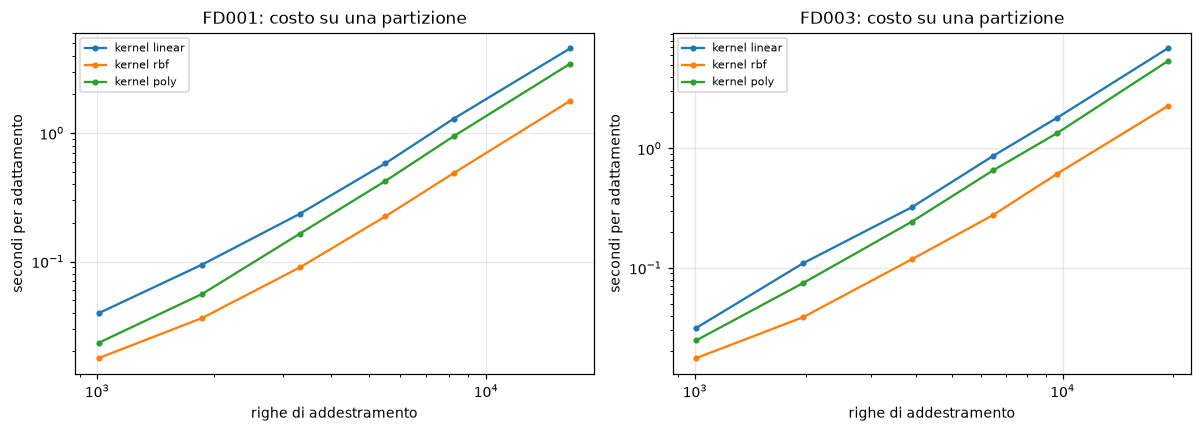

,sottoinsieme,kernel,righe_massime,secondi_a_righe_massime,esponente_empirico
0,FD001,linear,16435,4.567837,1.828411
1,FD001,rbf,16435,1.783271,1.878656
2,FD001,poly,16435,3.467566,1.884905
3,FD003,linear,19303,6.881056,1.930063
4,FD003,rbf,19303,2.260976,1.881014
5,FD003,poly,19303,5.375463,2.000829


In [10]:
ladder = {s: probe[s].query("block == 'ladder' and status == 'ok'") for s in SUBSETS}

fig, axes = plt.subplots(1, len(SUBSETS), figsize=(11, 4))
esponenti = []
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    for kernel in KERNELS:
        part = ladder[subset][ladder[subset]["kernel"] == kernel].sort_values("n_train_rows")
        ax.plot(part["n_train_rows"], part["fit_seconds"], marker=".", label=f"kernel {kernel}")
        # Esponente empirico fra i due punti piu' grandi, che e' la regione in cui la crescita
        # va estrapolata alla dimensione piena.
        last, second = part.iloc[-1], part.iloc[-2]
        esponenti.append({
            "sottoinsieme": subset,
            "kernel": kernel,
            "righe_massime": int(last["n_train_rows"]),
            "secondi_a_righe_massime": last["fit_seconds"],
            "esponente_empirico": np.log(last["fit_seconds"] / second["fit_seconds"])
                                  / np.log(last["n_train_rows"] / second["n_train_rows"]),
        })
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("righe di addestramento")
    ax.set_ylabel("secondi per adattamento")
    ax.set_title(f"{subset}: costo su una partizione")
    ax.legend(fontsize=7)
save(fig, "costo_stima_margine")
plt.show()

costi = pd.DataFrame(esponenti)
costi.to_csv(TABLES_DIR / "costo_stima_margine.csv", index=False)
costi

In [11]:
rows = []
for subset in SUBSETS:
    block = probe[subset].query("block == 'degree'").copy()
    block = block[["kernel", "gamma", "degree", "n_train_rows", "status",
                   "fit_seconds", "convergence_warnings", "rmse"]]
    block.insert(0, "sottoinsieme", subset)
    rows.append(block)
grado = pd.concat(rows, ignore_index=True)
grado.to_csv(TABLES_DIR / "grado_kernel_polinomiale.csv", index=False)
grado

,sottoinsieme,kernel,gamma,degree,n_train_rows,status,fit_seconds,convergence_warnings,rmse
0,FD001,poly,0.15,2.0,16435,ok,19.959962,0.0,110.061168
1,FD001,poly,0.15,3.0,16435,ok,179.904449,1.0,24.954013
2,FD001,poly,0.15,4.0,16435,ok,762.540399,1.0,95.750861
3,FD001,poly,0.50,2.0,16435,ok,119.244118,1.0,111.728333
4,FD001,poly,0.50,3.0,16435,ok,1504.315228,1.0,30.842483
5,FD001,poly,0.50,4.0,16435,oltre il limite,1800.000000,NaN,NaN


Le curve del costo sono rette in scala doppiamente logaritmica con pendenza fra 1,8 e 2,1: la
crescita e' quadratica nel numero di righe, non cubica. A dimensione piena l'adattamento richiede
pochi secondi sulla configurazione centrale e alcune decine sull'angolo piu' oneroso, il che rende
il blocco eseguibile sotto il protocollo pieno, sulla matrice intera, senza sottocampionamenti e
senza trattamenti differenziati rispetto agli altri blocchi.

La tabella sul grado del kernel polinomiale documenta due scelte prese prima dell'esecuzione e
spiega il risultato di quel modello.

Il valore del kernel polinomiale e' il prodotto interno fra due righe, moltiplicato per l'ampiezza
ed elevato al grado. Con diciotto colonne standardizzate il prodotto interno e' dell'ordine delle
diciotto unita', quindi appena l'ampiezza supera l'inverso del numero di colonne la matrice del
kernel assume valori di ampiezza crescente e il problema che l'ottimizzatore risolve diventa mal
condizionato. La misura lo mostra in due modi: le stime raggiungono il tetto sul numero di
iterazioni, e l'errore diventa erratico, con lo stesso punto che produce 110,1 cicli su FD001 e
18,5 su FD003, cioe' un fattore sei di differenza fra due sottoinsiemi che tutti gli altri modelli
trattano quasi allo stesso modo. Il kernel radiale non ha questo problema, perche' il suo valore
resta in ogni caso fra zero e uno, e la sua griglia dell'ampiezza puo' estendersi oltre.

Da qui le due scelte. Il grado resta fissato a 3, come nel laboratorio, perche' il grado 4 richiede
fra i 760 e i 1.370 secondi per singolo adattamento contro i 24 e 42 del grado 3, e in entrambi i
casi produce una stima troncata, il cui punteggio non sarebbe confrontabile con gli altri della
griglia. L'estremo superiore dell'ampiezza del kernel polinomiale e' un bordo strutturale: oltre
non c'e' un modello migliore, c'e' una stima che non converge.

La conseguenza va dichiarata e non attenuata. La ricerca seleziona quell'estremo su entrambi i
sottoinsiemi, e il profilo del modello lungo quell'asse e' ancora in discesa quando la griglia
finisce. La riga del kernel polinomiale e' quindi un limite superiore delle sue prestazioni sotto
una parametrizzazione numericamente sana, non una misura di quanto la tecnica valga in assoluto.

## 5. Dove fermare la stima della rete

Il numero massimo di iterazioni della rete e' in griglia, mentre il numero di alberi degli insiemi
per aggregazione del blocco precedente era fissato. La differenza non e' una disparita' di
trattamento: le due quantita' si comportano in modo diverso.

L'errore di un insieme per aggregazione decresce in valore atteso in modo monotono nel numero di
alberi e satura, quindi quel parametro governa la precisione di una media e non un compromesso. La
perdita di addestramento di una rete continua a scendere mentre l'errore di verifica risale, quindi
il punto in cui la stima si ferma governa un compromesso e va selezionato come tale.

La curva che segue e' la verifica di questa affermazione, misurata prima di fissare le griglie su
una sola partizione, aggiungendo iterazioni a una rete gia' addestrata invece di riaddestrarla a
ogni punto.

/var/folders/9r/0bn526_x0vs8kxm32fpw79b80000gn/T/ipykernel_52344/1943369831.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


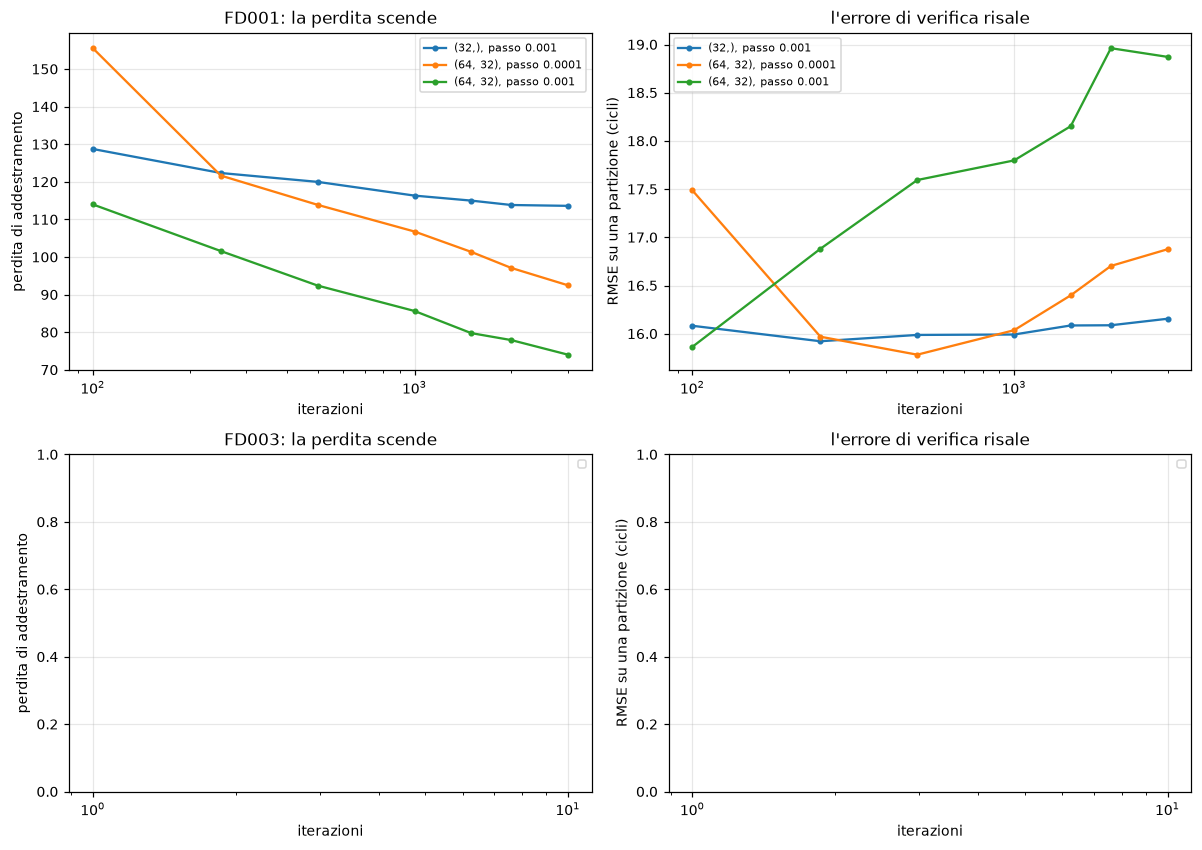

In [12]:
curve = {s: network_probe[s].query("block == 'curve' and status == 'ok'") for s in SUBSETS}

fig, axes = plt.subplots(len(SUBSETS), 2, figsize=(11, 3.9 * len(SUBSETS)))
axes = np.atleast_2d(axes)
for row_axes, subset in zip(axes, SUBSETS):
    block = curve[subset]
    for (architecture, rate), part in block.groupby(["hidden_layer_sizes", "learning_rate_init"]):
        part = part.sort_values("iterations_target")
        label = f"{architecture}, passo {rate:g}"
        row_axes[0].plot(part["iterations_target"], part["loss"], marker=".", label=label)
        row_axes[1].plot(part["iterations_target"], part["rmse"], marker=".", label=label)
    row_axes[0].set_ylabel("perdita di addestramento")
    row_axes[1].set_ylabel("RMSE su una partizione (cicli)")
    for ax in row_axes:
        ax.set_xscale("log")
        ax.set_xlabel("iterazioni")
        ax.legend(fontsize=7)
    row_axes[0].set_title(f"{subset}: la perdita scende")
    row_axes[1].set_title("l'errore di verifica risale")
save(fig, "convergenza_rete")
plt.show()

Le due colonne della figura vanno lette insieme. La perdita di addestramento scende in modo
monotono su tutte le architetture, come deve fare una procedura di ottimizzazione che funziona.
L'errore sulla parte di verifica della partizione raggiunge un minimo presto, fra cento e cinquecento
iterazioni a seconda dell'architettura, e poi risale: sull'architettura a due strati con passo
grande passa da circa 15,9 a circa 18,9 cicli fra cento e tremila iterazioni, mentre la perdita
scende da 114 a 74. La rete sta continuando ad adattarsi ai dati di addestramento dopo che ha
smesso di migliorare su quelli che non ha visto.

Ne segue che fermare la stima e' una forma di regolarizzazione, e che il punto in cui fermarla e'
un iperparametro. La griglia dell'esperimento lo contiene, e la configurazione selezionata su FD003
si ferma a 250 iterazioni, cioe' molto prima del limite del laboratorio.

Va segnalata una asimmetria fra i due meccanismi di arresto della libreria. Oltre al limite sul
numero di iterazioni esiste un criterio interno che confronta il miglioramento della perdita con
una tolleranza fissa; poiche' la perdita qui e' nell'ordine delle centinaia di cicli al quadrato,
quel criterio interviene solo su alcune configurazioni. Sulla configurazione selezionata su FD001
interviene: il limite e' di mille iterazioni e la stima si ferma a 592 quando viene riaddestrata
sull'intera parte di addestramento, ed e' il motivo per cui le configurazioni con limite a mille e
a duemila iterazioni hanno punteggi identici. L'arresto anticipato con partizione interna, che
sarebbe il terzo meccanismo disponibile, non e' stato usato: la partizione che costruisce e'
ottenuta mescolando le righe, quindi collocherebbe cicli adiacenti dello stesso motore da entrambe
le parti, che e' la contaminazione che il vincolo di gruppo del protocollo esiste per escludere.

## 6. Quali variabili pesano

Nessuno dei tre modelli non lineari di questo blocco espone coefficienti sulle variabili
originali, quindi la sola lettura disponibile e' l'importanza per permutazione: di quanto peggiora
l'errore quando i valori di una variabile vengono mescolati fra le righe. La misura e' calcolata
su dati non usati per l'addestramento, cioe' sulla parte di verifica di ciascuna delle cinque
partizioni del seme di ricerca, con il modello riaddestrato sulla parte di addestramento della
stessa partizione. L'insieme di verifica ufficiale resta chiuso fino alla chiusura della
graduatoria.

E' la stessa misura, con lo stesso numero di ripetizioni e sulle stesse partizioni, usata nel
blocco della famiglia ad albero: i valori sono percio' confrontabili fra i due blocchi. Il valore
e' in cicli ed e' l'aumento della metrica di riferimento.

Cautela di lettura, valida qui come li': fra variabili correlate l'importanza per permutazione si
ripartisce e in parte si annulla, perche' mescolare una variabile lascia al modello l'informazione
che le altre portano al suo posto. Un valore basso non e' una prova che la variabile sia inutile.

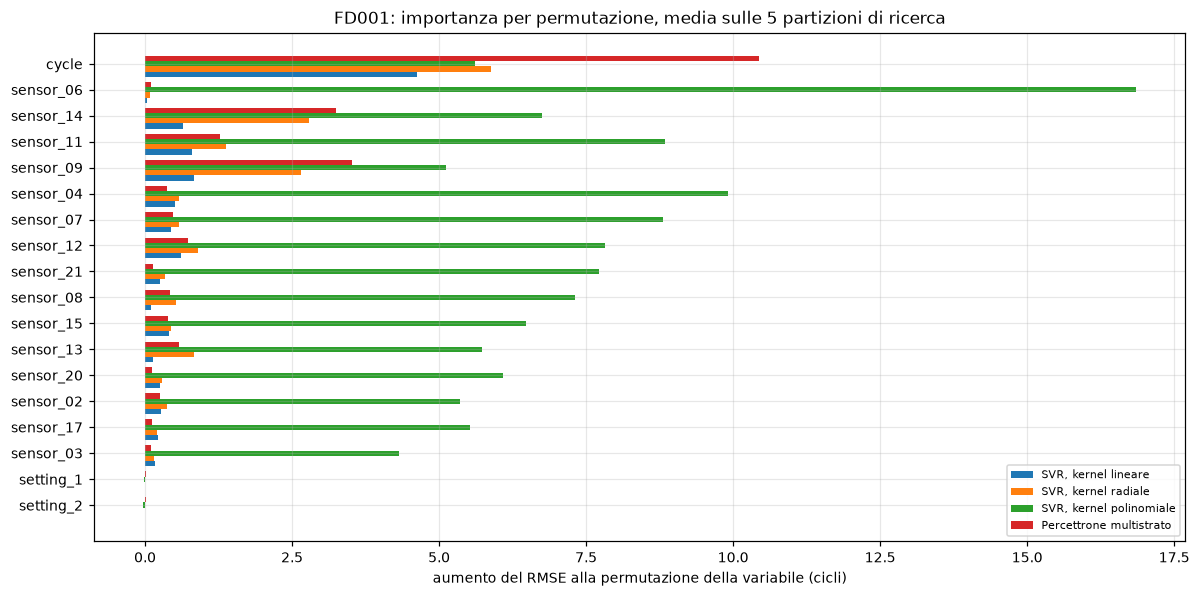

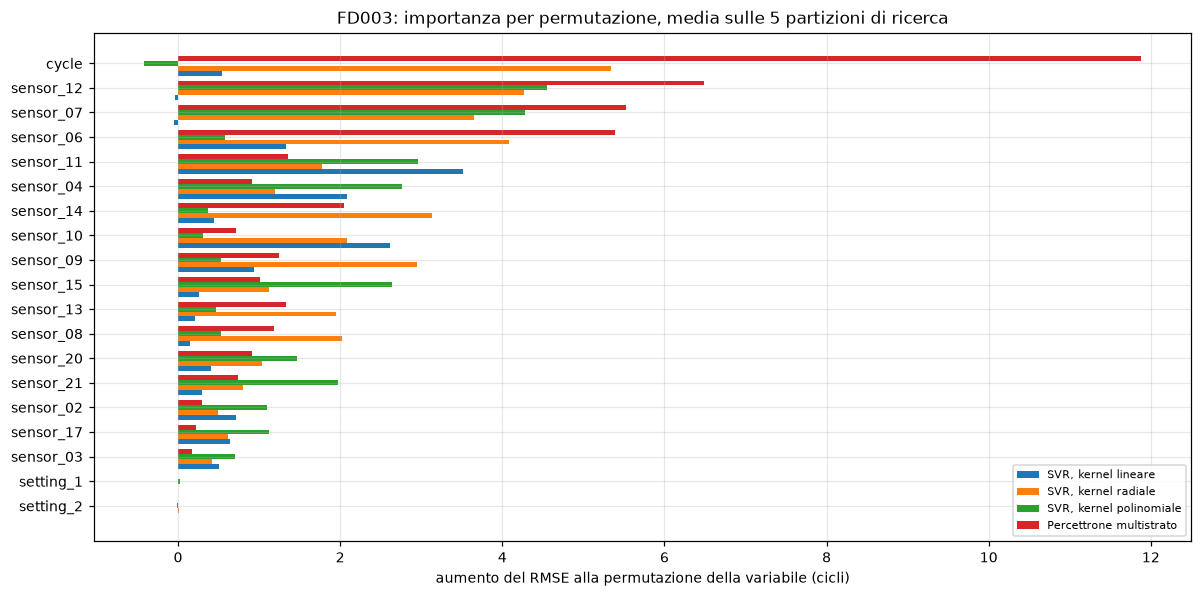

In [13]:
for subset in SUBSETS:
    wide = permutation[subset].pivot(index="feature", columns="model", values="importance_mean")
    wide = wide[[m for m in MODELS if m in wide.columns]]
    wide = wide.loc[wide.mean(axis=1).sort_values().index]
    fig, ax = plt.subplots(figsize=(11, 5.5))
    y = np.arange(len(wide))
    height = 0.8 / wide.shape[1]
    for i, model in enumerate(wide.columns):
        ax.barh(y + (i - wide.shape[1] / 2) * height, wide[model], height=height,
                label=LABELS[model])
    ax.set_yticks(y)
    ax.set_yticklabels(wide.index)
    ax.set_xlabel("aumento del RMSE alla permutazione della variabile (cicli)")
    ax.set_title(f"{subset}: importanza per permutazione, media sulle 5 partizioni di ricerca")
    ax.legend(fontsize=7)
    save(fig, f"{subset}_importanze_permutazione_margine")
    plt.show()

In [14]:
rows = []
for subset in SUBSETS:
    for model in MODELS:
        block = permutation[subset].query("model == @model").set_index("feature")
        ordered = block["importance_mean"].sort_values(ascending=False)
        total = ordered.clip(lower=0).sum()
        rows.append({
            "sottoinsieme": subset,
            "modello": LABELS[model],
            "variabile_principale": ordered.index[0],
            "importanza_principale_cicli": ordered.iloc[0],
            "permutazione_ciclo_cicli": block["importance_mean"].get("cycle", np.nan),
            "quota_prime_tre": ordered.head(3).clip(lower=0).sum() / total if total > 0 else np.nan,
            "variabili_sotto_un_decimo_di_ciclo": int((ordered < 0.1).sum()),
        })
letture = pd.DataFrame(rows)
letture.to_csv(TABLES_DIR / "importanze_permutazione_margine.csv", index=False)
letture

,sottoinsieme,modello,variabile_principale,importanza_principale_cicli,permutazione_ciclo_cicli,quota_prime_tre,variabili_sotto_un_decimo_di_ciclo
0,FD001,"SVR, kernel lineare",cycle,4.630845,4.630845,0.606834,3
1,FD001,"SVR, kernel radiale",cycle,5.879753,5.879753,0.627913,3
2,FD001,"SVR, kernel polinomiale",sensor_06,16.847750,5.611832,0.301170,2
3,FD001,Percettrone multistrato,cycle,10.437531,10.437531,0.771503,3
4,FD003,"SVR, kernel lineare",sensor_11,3.510336,0.542565,0.560569,4
5,FD003,"SVR, kernel radiale",cycle,5.343344,5.343344,0.370494,2
6,FD003,"SVR, kernel polinomiale",sensor_12,4.548294,-0.424822,0.447143,3
7,FD003,Percettrone multistrato,cycle,11.883147,11.883147,0.576739,2


Sui due modelli che raggiungono il gruppo di testa il numero di ciclo e' la variabile piu'
rilevante su entrambi i sottoinsiemi, con un aumento di errore fra 5,3 e 11,9 cicli alla sua
permutazione, seguito dagli stessi sensori che il blocco della famiglia ad albero indica come
rilevanti. La concordanza fra famiglie molto diverse e' essa stessa un risultato: l'ordinamento
delle variabili non e' un artefatto della classe di modelli scelta.

Il peso del numero di ciclo va letto insieme alla costruzione del target. Su traiettorie che
arrivano tutte al guasto la vita residua e' per costruzione la differenza fra durata e ciclo
corrente, quindi una parte della capacita' predittiva di qualunque modello proviene da un
conteggio e non dalla lettura del degrado. E' il motivo per cui il confronto contiene una baseline
che usa il solo numero di ciclo, e il divario fra quella baseline e i modelli misura cio' che i
sensori aggiungono.

Le due varianti di kernel che restano indietro hanno ordinamenti diversi, e la differenza va letta
con la cautela dichiarata sopra invece che come una lettura alternativa alla pari. Il kernel
lineare su FD003 distribuisce l'importanza fra i sensori e assegna al numero di ciclo 0,54 cicli,
contro i 4,63 dello stesso modello su FD001: la configurazione selezionata li' e' quella con
penalizzazione minima e banda ampia, cioe' una funzione molto piatta, e su una funzione piatta la
permutazione di una singola variabile sposta poco e il peso si ripartisce fra variabili correlate.
Il kernel polinomiale colloca il numero di ciclo in dodicesima posizione su FD001 e in ultima su
FD003, dove l'aumento di errore alla permutazione e' addirittura negativo: mescolare quella
variabile migliora leggermente la predizione. Un valore negativo indica che il modello sta usando
la variabile in un modo che non aiuta, ed e' coerente con una funzione stimata in una regione di
parametri in cui la griglia lo costringe.

## 7. Diagnostica dell'esperimento

La tabella raccoglie cio' che e' successo durante la ricerca su griglia e che non compare nei
punteggi: quante configurazioni sono state valutate, se la configurazione selezionata cada su un
estremo della griglia, quante configurazioni non siano state valutabili, quante mancate
convergenze si siano verificate.

Il conteggio delle mancate convergenze va letto in modo diverso sulle due famiglie di questo
blocco. Sui modelli a margine segnala una stima interrotta dal tetto sul numero di iterazioni,
cioe' un punteggio non confrontabile con gli altri. Sulla rete segnala che l'ottimizzazione ha
raggiunto il numero di iterazioni previsto, che qui e' il meccanismo voluto e non un difetto.

In [15]:
rows = []
for subset in SUBSETS:
    block = diagnostics[subset].copy()
    block.insert(0, "sottoinsieme", subset)
    rows.append(block)
diagnostica = pd.concat(rows, ignore_index=True)
colonne = ["sottoinsieme", "model", "n_configurations", "boundary", "failed_configurations",
           "convergence_warnings", "n_support", "support_share", "n_parameters",
           "stopped_at_max_iter", "search_seconds"]
diagnostica = diagnostica[[c for c in colonne if c in diagnostica.columns]]
diagnostica.to_csv(TABLES_DIR / "diagnostica_blocco_margine.csv", index=False)

print("configurazioni non valutabili in tutto il blocco:",
      int(diagnostica["failed_configurations"].fillna(0).sum()))
print("stime interrotte dal tetto sulle iterazioni, modelli a margine:",
      int(diagnostica.query("model != 'mlp'")["convergence_warnings"].fillna(0).sum()))
diagnostica

configurazioni non valutabili in tutto il blocco: 0
stime interrotte dal tetto sulle iterazioni, modelli a margine: 0


,sottoinsieme,model,n_configurations,boundary,failed_configurations,convergence_warnings,n_support,support_share,n_parameters,stopped_at_max_iter,search_seconds
0,FD001,svr_linear,35,model__C=minimo,0,0,9174.0,0.444671,NaN,NaN,270.251900
1,FD001,svr_rbf,150,NaN,0,0,10073.0,0.488246,NaN,NaN,5195.363669
2,FD001,svr_poly,140,model__gamma=massimo,0,0,10776.0,0.522321,NaN,NaN,1089.999471
3,FD001,mlp,175,NaN,0,0,NaN,NaN,321.0,False,2138.452491
4,FD003,svr_linear,35,model__C=minimo,0,0,15933.0,0.644539,NaN,NaN,645.626582
5,FD003,svr_rbf,150,NaN,0,0,12789.0,0.517354,NaN,NaN,10504.322103
6,FD003,svr_poly,140,model__gamma=massimo,0,0,13424.0,0.543042,NaN,NaN,1561.906585
7,FD003,mlp,175,model__hidden_layer_sizes=massimo,0,1,NaN,NaN,10881.0,True,2096.740278


Nessuna configurazione e' risultata non valutabile e nessuna stima a margine e' stata interrotta
dal tetto sul numero di iterazioni: la protezione fissata prima dell'esecuzione non ha dovuto
intervenire su nessuna delle configurazioni in griglia, il che e' la conferma che i bordi delle
griglie erano stati posti dentro la regione in cui la stima converge.

Restano selezionati tre estremi, e la regola sui bordi li tratta in modo diverso perche' la
distinzione fra bordi veri e bordi strutturali era stata fissata prima di vedere i risultati.

La penalizzazione minima del kernel lineare e' selezionata su entrambi i sottoinsiemi, ma il
profilo lungo quell'asse varia di meno di un decimo di ciclo su quattro decadi. L'estensione
prevista dalla regola e' stata eseguita, e ha spostato il modello di 0,002 cicli su FD001 e di
0,118 su FD003, contro dispersioni fra fold di 1,12 e 1,52. La catena si e' chiusa per il criterio
fissato a priori: un'estensione che sposta il modello di meno della dispersione ha raggiunto la
regione in cui il protocollo non distingue, e continuare a estendere inseguirebbe differenze che il
progetto stesso dichiara illeggibili.

L'architettura piu' capiente della rete e' selezionata su FD003. Anche qui l'estensione e' stata
eseguita, aggiungendo una rete piu' larga, e ha spostato il modello di 0,003 cicli contro una
dispersione di 1,06: il profilo lungo la capacita' e' ripido in basso e piatto in cima, quindi il
guadagno marginale dell'allargamento si e' esaurito dentro la griglia.

L'ampiezza massima del kernel polinomiale e' il bordo strutturale discusso nella sezione sul costo
della stima, e non produce estensione.

Le estensioni eseguite hanno riguardato sette assi in tutto e sono state applicate a entrambi i
sottoinsiemi anche quando il bordo si era manifestato su uno solo, perche' griglie diverse fra i
due renderebbero le due repliche del confronto non piu' condotte sotto lo stesso protocollo. I
valori aggiunti sono rimasti in griglia con i loro punteggi anche quando peggiori: rimuoverli a
posteriori sarebbe una selezione sulla griglia stessa.

## 8. Sintesi del blocco

Il percettrone multistrato e la regressione a vettori di supporto con kernel radiale raggiungono
il livello del miglior modello dei blocchi precedenti e non lo superano in modo leggibile: i
divari sono frazioni di dispersione su entrambi i sottoinsiemi. La conclusione difendibile e' che
tre famiglie costruite su principi diversi, partizioni ricorsive, espansioni di base e funzioni
stimate implicitamente, convergano sullo stesso livello di errore. E' un risultato piu'
informativo di una graduatoria: dice che il limite osservato dipende dal problema e dalla
rappresentazione dei dati piu' che dalla classe di modelli.

Le due varianti di kernel restanti stanno indietro in modo leggibile. Il kernel lineare arriva
dove arrivano i modelli lineari, il che e' una conferma di coerenza del protocollo fra blocchi: la
stessa forma funzionale, stimata minimizzando una perdita diversa, produce lo stesso errore a due
decimali. Il kernel polinomiale e' peggiore del kernel lineare, per la ragione numerica documentata.

L'asimmetria fra i due sottoinsiemi si presenta qui in una forma nuova rispetto ai blocchi
precedenti. Non riguarda solo il livello di errore ma la capacita' richiesta: la rete migliore su
FD001 e' la piu' stretta della griglia e quella su FD003 e' la piu' larga, con profili di segno
opposto lungo lo stesso asse. Due modi di guasto invece di uno chiedono una funzione piu'
articolata, e questo blocco e' quello in cui la richiesta si legge direttamente su un
iperparametro.

Cinque limiti vanno dichiarati.

I punteggi sono ottimistici, perche' la cross-validation non e' annidata e la ricerca degli
iperparametri usa le stesse partizioni su cui la prestazione viene poi misurata. In questo blocco
il numero di configurazioni esplorate varia da 35 a 175 fra le righe della stessa tabella, quindi
la distorsione da selezione non e' uniforme fra le righe: il protocollo e' identico per tutti, ma
il confronto non e' a parita' di questo fattore.

La riga del kernel polinomiale e' un limite superiore delle prestazioni della tecnica, non una sua
misura: la griglia dell'ampiezza del kernel e' chiusa dal lato in cui il profilo scende ancora, per
una ragione di condizionamento numerico e non di costo.

Il grado del kernel polinomiale e' fissato a 3 e non selezionato. La scelta e' motivata da una
misura, ma resta un parametro deciso fuori dalla ricerca, come il numero di alberi degli insiemi
nel blocco precedente.

La rete e' stimata con un solo seme di inizializzazione dei pesi. La dispersione riportata sui 15
fold contiene quindi la variabilita' dovuta alla partizione ma non quella dovuta
all'inizializzazione, che per questa classe di modelli non e' trascurabile. Il confronto e' equo,
perche' tutti i modelli che richiedono un seme ne ricevono uno fissato, ma la dispersione della
riga della rete e' sottostimata rispetto alla variabilita' complessiva della procedura.

Tutte le misure di questo notebook sono in cross-validation. Nessuna riga dell'insieme di verifica
ufficiale e' stata letta, e la stima non condizionata dalle scelte del progetto arrivera' solo a
graduatoria chiusa.